<a href="https://colab.research.google.com/github/vyasathul17/Machine-Learning/blob/main/Decision_Tree_Professional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [63]:
from google.colab import files
uploaded = files.upload()

Saving Pokemon.csv to Pokemon (2).csv


In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

#Load data

In [65]:
data = pd.read_csv("Pokemon.csv")
data

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,719,Diancie,Rock,Fairy,600,50,100,150,100,150,50,6,True
796,719,DiancieMega Diancie,Rock,Fairy,700,50,160,110,160,110,110,6,True
797,720,HoopaHoopa Confined,Psychic,Ghost,600,80,110,60,150,130,70,6,True
798,720,HoopaHoopa Unbound,Psychic,Dark,680,80,160,60,170,130,80,6,True


In [66]:
df_original = data.copy()

In [67]:
data.columns

Index(['#', 'Name', 'Type 1', 'Type 2', 'Total', 'HP', 'Attack', 'Defense',
       'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary'],
      dtype='object')

#Data cleaning

In [68]:
#Drop unnecessary column

if "#" in data.columns:
  data = data.drop("#",axis = 1)

In [69]:
data.columns

Index(['Name', 'Type 1', 'Type 2', 'Total', 'HP', 'Attack', 'Defense',
       'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary'],
      dtype='object')

In [70]:
#clean column names

data.columns = data.columns.str.strip().str.replace(" ","_")

In [71]:
data.columns

Index(['Name', 'Type_1', 'Type_2', 'Total', 'HP', 'Attack', 'Defense',
       'Sp._Atk', 'Sp._Def', 'Speed', 'Generation', 'Legendary'],
      dtype='object')

In [72]:
#Null values
data.isnull().sum()

,0
Name,0
Type_1,0
Type_2,386
Total,0
HP,0
Attack,0
Defense,0
Sp._Atk,0
Sp._Def,0
Speed,0


In [73]:
#Fill categorical missing value
cat_cols = data.select_dtypes(include = "object").columns
data[cat_cols]= data[cat_cols].fillna("Missing")

#fill Numerical missing values with median
num_col = data.select_dtypes(exclude = "object").columns
data[num_col] = data[num_col].fillna(data[num_col].median())

In [74]:
data.isnull().sum()

,0
Name,0
Type_1,0
Type_2,0
Total,0
HP,0
Attack,0
Defense,0
Sp._Atk,0
Sp._Def,0
Speed,0


#EDA(Exploratory Data Analysis)

In [75]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Name        800 non-null    object
 1   Type_1      800 non-null    object
 2   Type_2      800 non-null    object
 3   Total       800 non-null    int64 
 4   HP          800 non-null    int64 
 5   Attack      800 non-null    int64 
 6   Defense     800 non-null    int64 
 7   Sp._Atk     800 non-null    int64 
 8   Sp._Def     800 non-null    int64 
 9   Speed       800 non-null    int64 
 10  Generation  800 non-null    int64 
 11  Legendary   800 non-null    bool  
dtypes: bool(1), int64(8), object(3)
memory usage: 69.7+ KB


In [76]:
data.describe()

,Total,HP,Attack,Defense,Sp._Atk,Sp._Def,Speed,Generation
count,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000
mean,435.10250,69.258750,79.001250,73.842500,72.820000,71.902500,68.277500,3.32375
std,119.96304,25.534669,32.457366,31.183501,32.722294,27.828916,29.060474,1.66129
min,180.00000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.00000
25%,330.00000,50.000000,55.000000,50.000000,49.750000,50.000000,45.000000,2.00000
50%,450.00000,65.000000,75.000000,70.000000,65.000000,70.000000,65.000000,3.00000
75%,515.00000,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000,5.00000
max,780.00000,255.000000,190.000000,230.000000,194.000000,230.000000,180.000000,6.00000


#Distribution plot

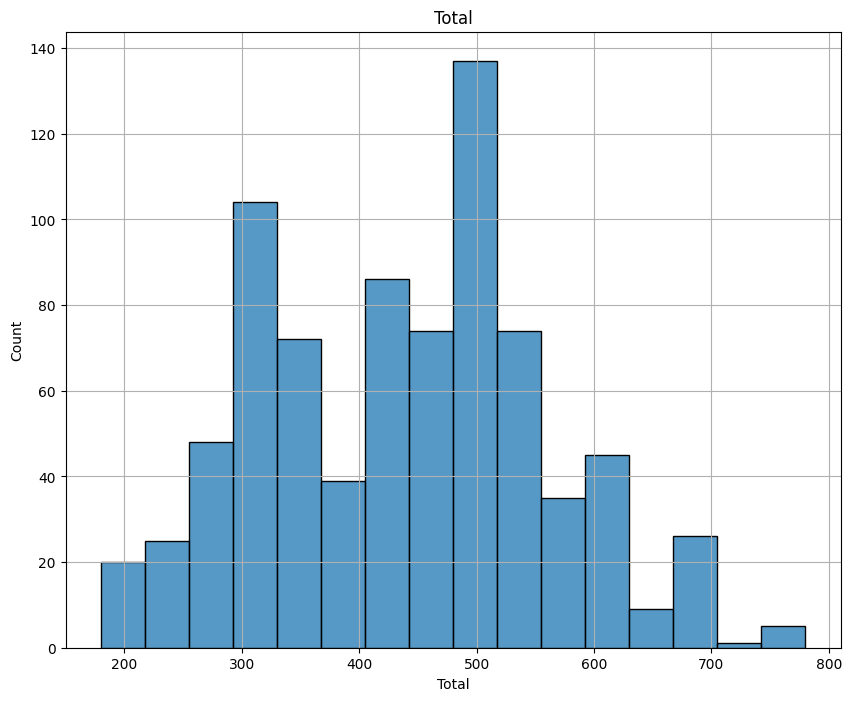

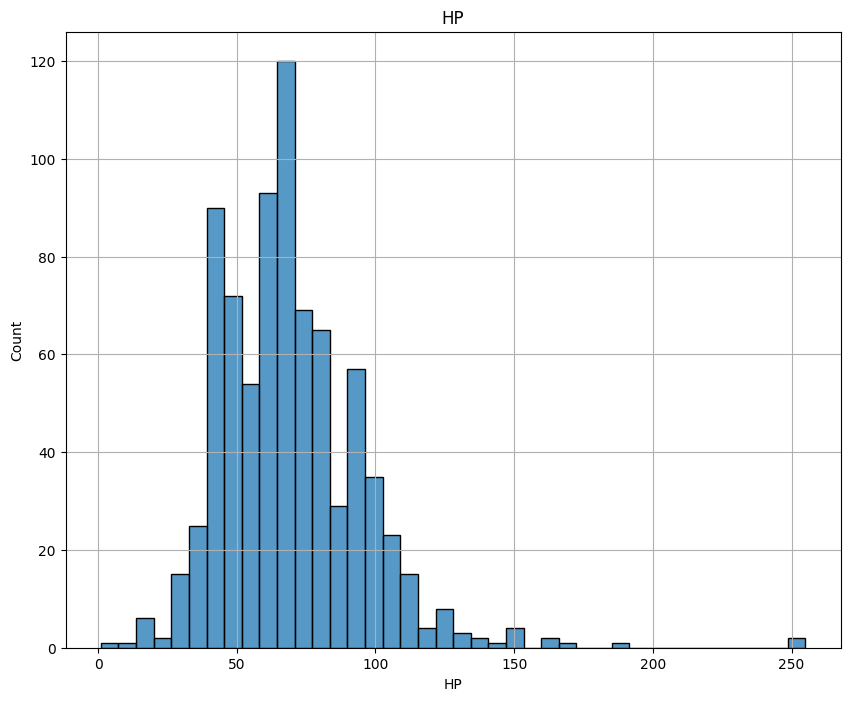

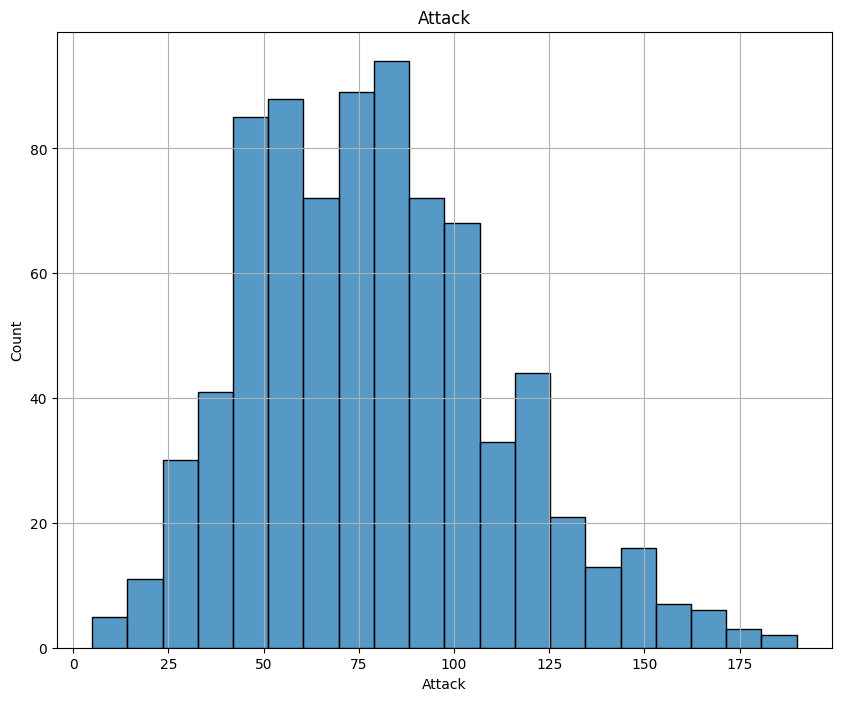

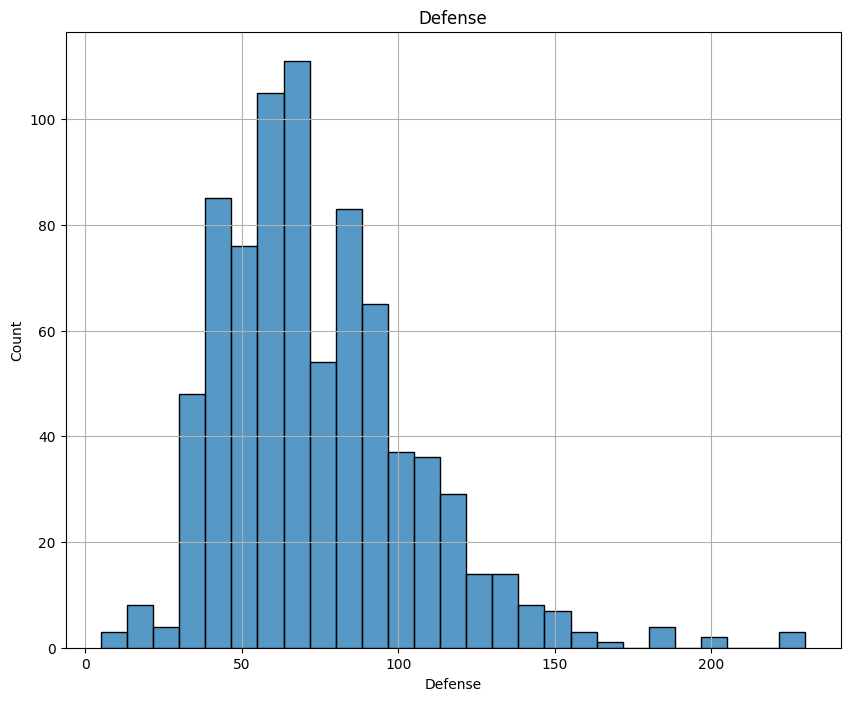

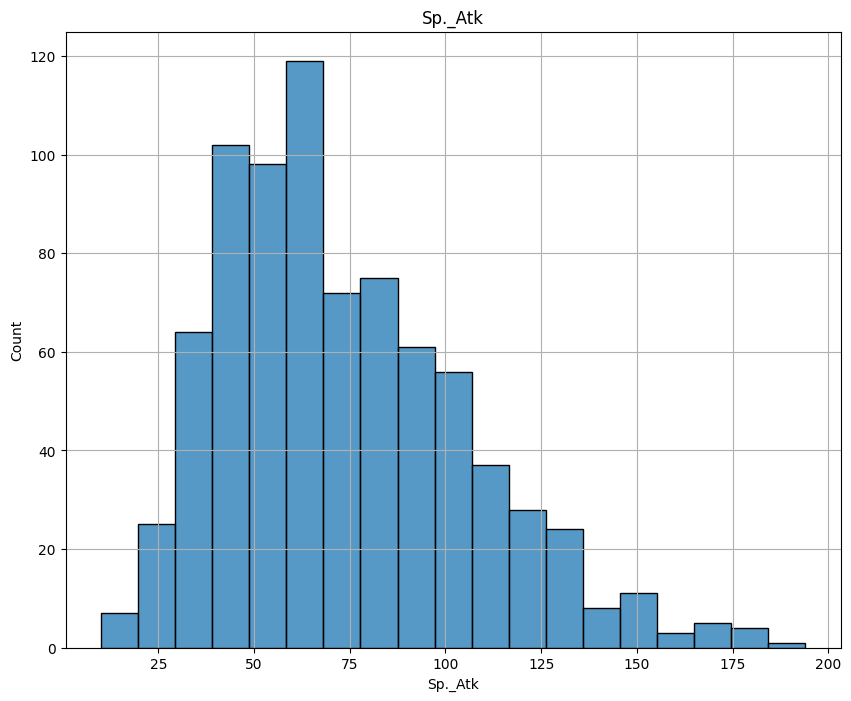

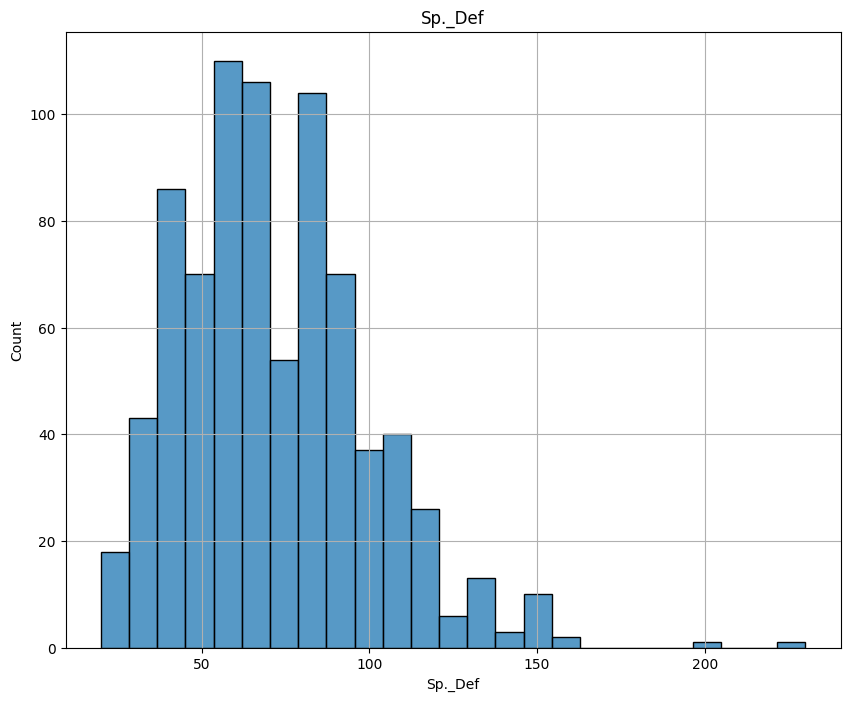

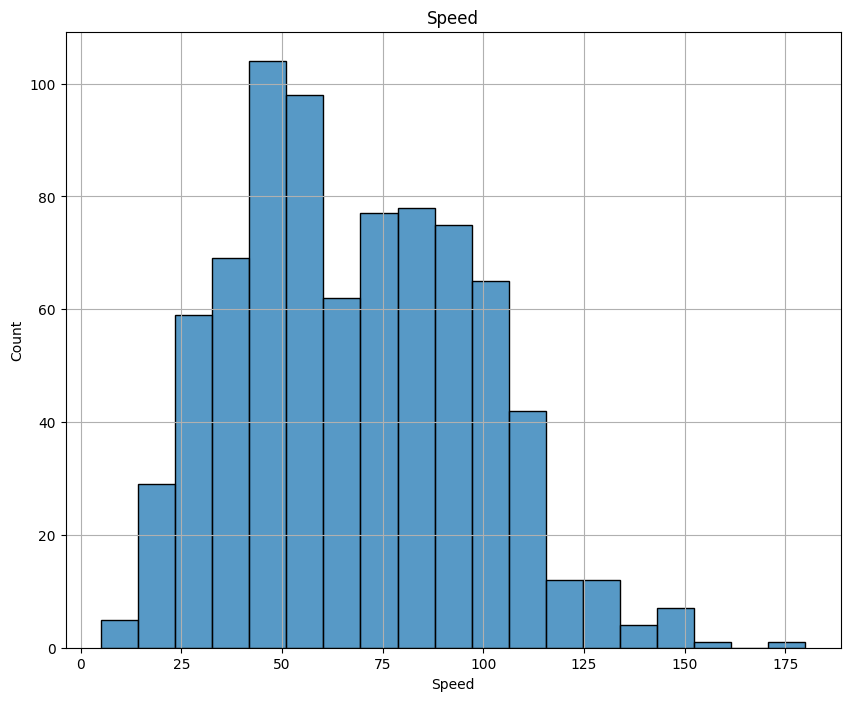

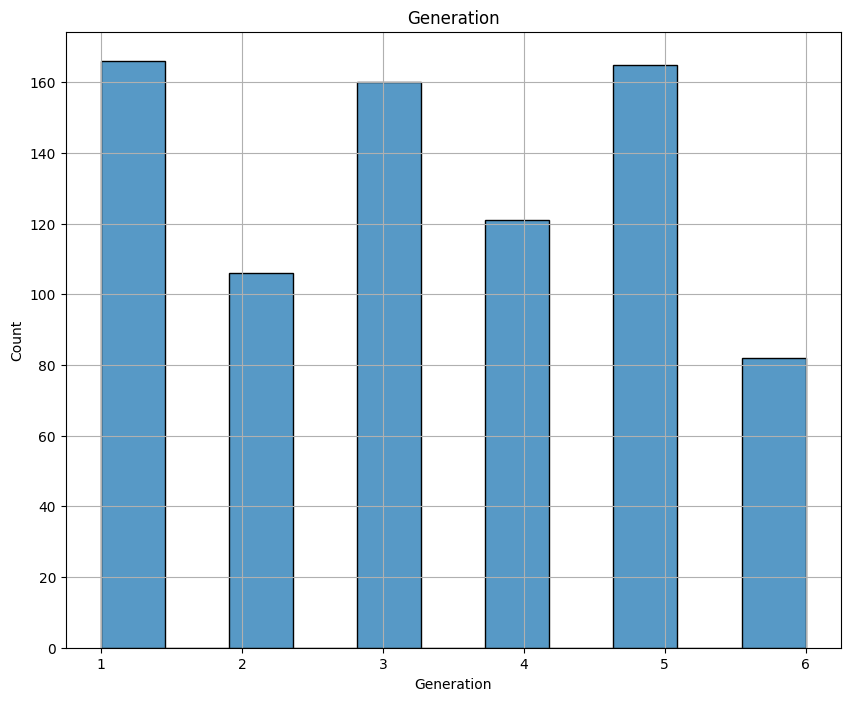

In [77]:
for col in data.columns:
  if((data[col].dtypes == "int64") | (data[col].dtypes == "float64")):
    plt.figure(figsize = (10,8))
    sns.histplot(data[col])
    plt.title(col)
    plt.grid()
    plt.show()

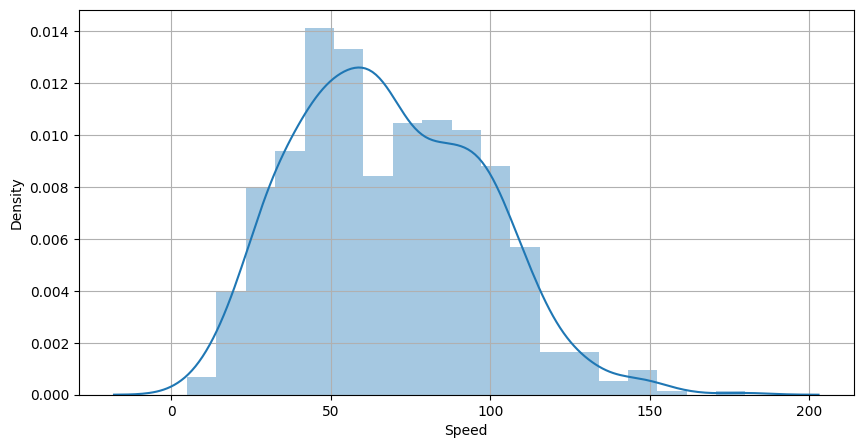

In [78]:
sns.distplot(data["Speed"])
plt.grid()
plt.show()

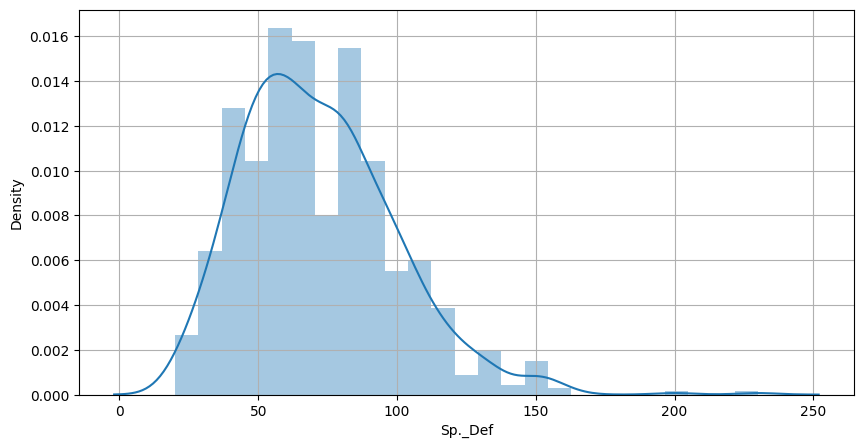

In [79]:
sns.distplot(data["Sp._Def"])
plt.grid()
plt.show()

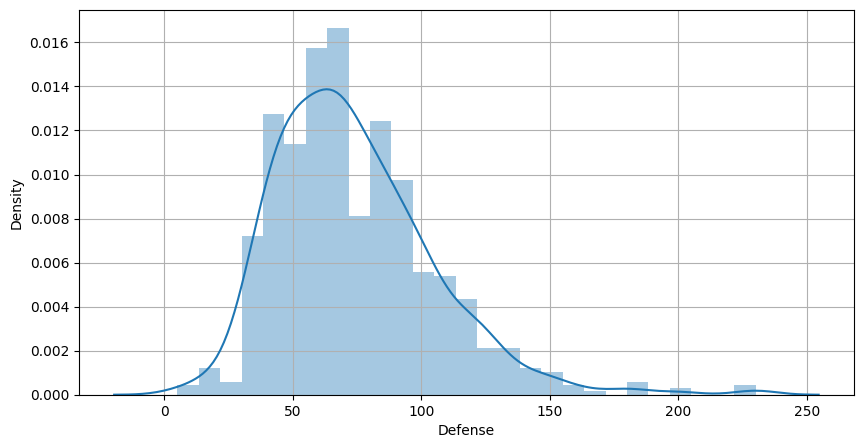

In [80]:
sns.distplot(data["Defense"])
plt.grid()
plt.show()

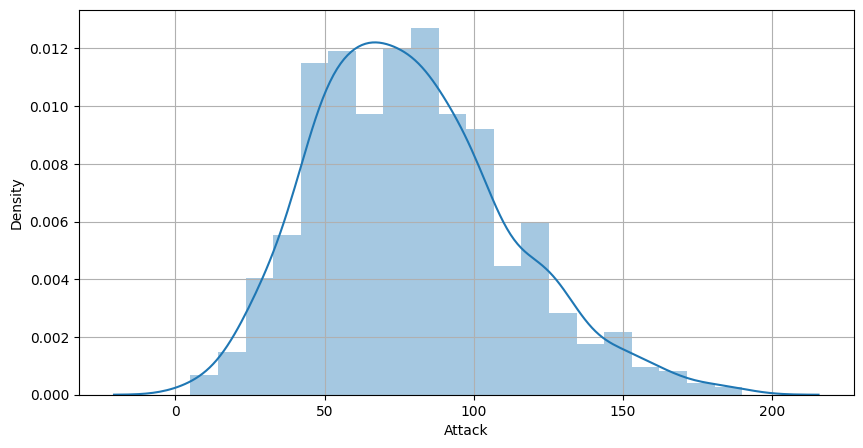

In [81]:
sns.distplot(data["Attack"])
plt.grid()
plt.show()

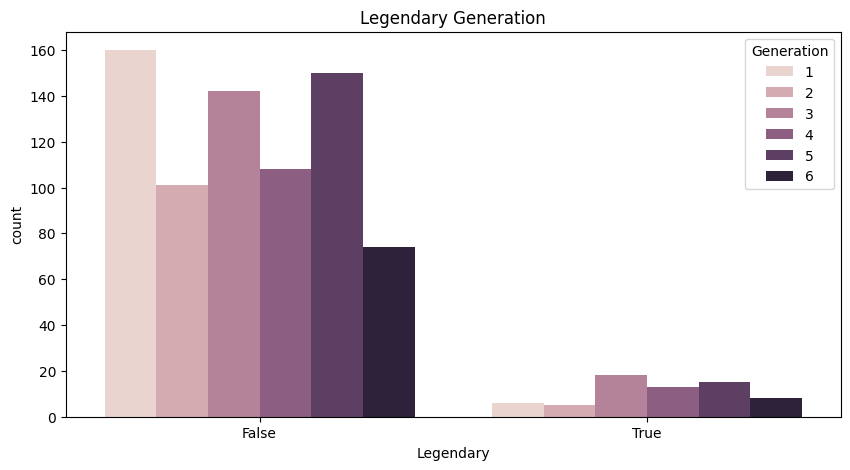

In [82]:
plt.rcParams["figure.figsize"] = (10,5)
sns.countplot(data=data,x = "Legendary",hue = "Generation")
plt.title("Legendary Generation")
plt.show()

#correlation HeatMap

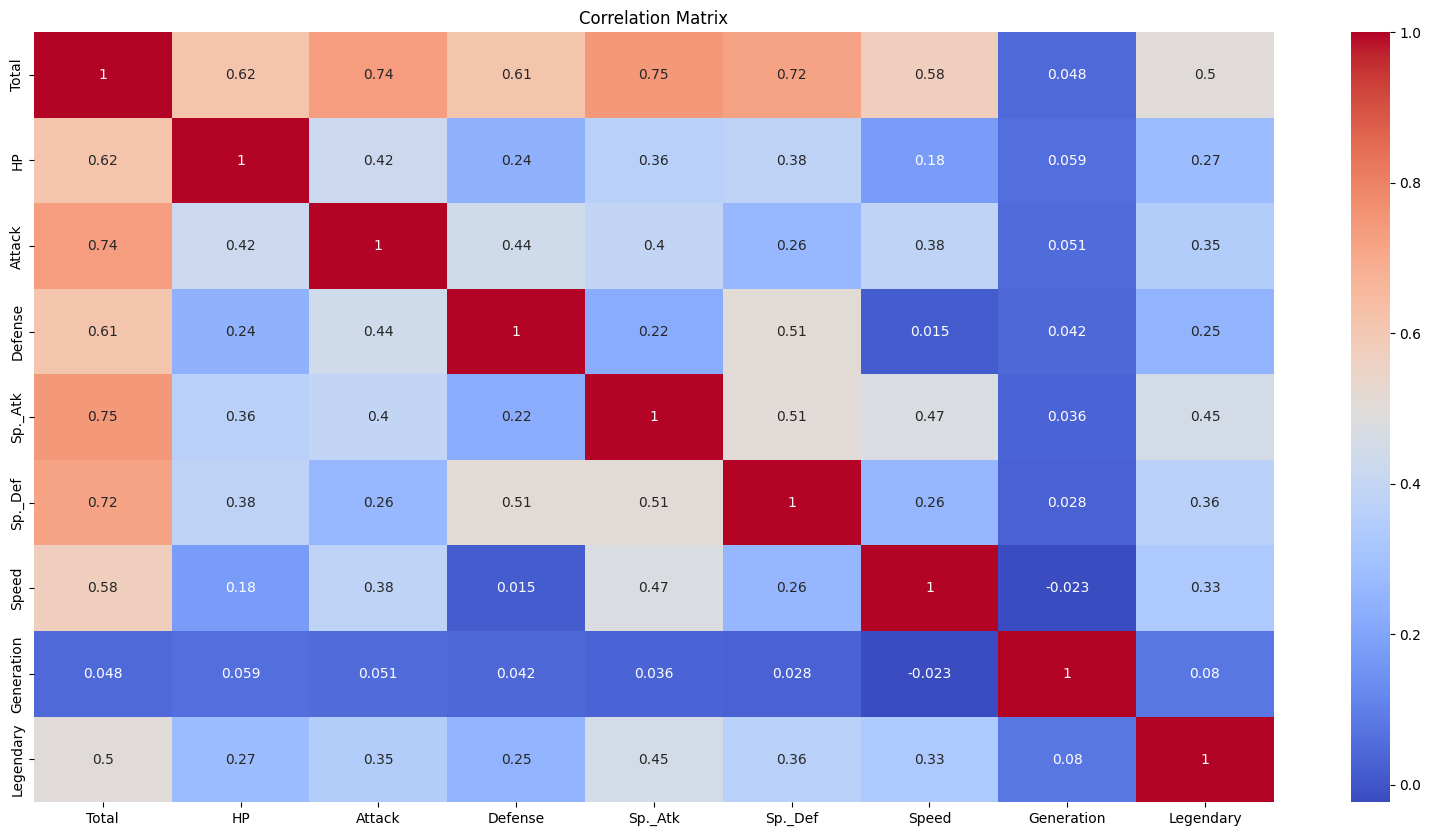

In [83]:
plt.figure(figsize = (20,10))
sns.heatmap(data.corr(numeric_only = True),annot = True,cmap = "coolwarm")
plt.title("Correlation Matrix")
plt.show()

#Feature Engineering
🔹 Convert categorical → numeric

In [84]:
from sklearn.preprocessing import OneHotEncoder

In [85]:
x = data.drop(["Legendary","Name"],axis = 1)
y = data["Legendary"]
y_final = y.map({True:1,False:0})

In [86]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y_final,train_size = 0.7,random_state = 42)

In [87]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [88]:
cat_cols = x_train.select_dtypes(include = "object").columns
num_cols = x_train.select_dtypes(exclude = "object").columns

preprocessor = ColumnTransformer(
    transformers = [("cat",OneHotEncoder(drop = "first",handle_unknown = "ignore"),cat_cols)],
    remainder = "passthrough"
)

pipeline = Pipeline(steps = [
    ("preprocessing",preprocessor),
    ("classifier",DecisionTreeClassifier(random_state = 42))
])

In [89]:
pipeline.fit(x_train,y_train)
pred = pipeline.predict(x_test)

In [91]:
print("Accuracy Score:",accuracy_score(y_test,pred))
print("\nconfusion Matrix:\n",confusion_matrix(y_test,pred))
print("\nclassification Report:\n",classification_report(y_test,pred))


Accuracy Score: 0.9666666666666667

confusion Matrix:
 [[220   5]
 [  3  12]]

classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.98       225
           1       0.71      0.80      0.75        15

    accuracy                           0.97       240
   macro avg       0.85      0.89      0.87       240
weighted avg       0.97      0.97      0.97       240



In [98]:
df_model = pipeline.named_steps["classifier"]
ohe = pipeline.named_steps["preprocessing"].named_transformers_["cat"]
encoded_feature = ohe.get_feature_names_out(cat_cols)
all_feature = list(encoded_feature)+list(num_cols)
importance = df_model.feature_importances_
feature_importance = pd.Series(importance,index = all_feature).sort_values(ascending = False)
print(feature_importance.head())

Total         0.547866
HP            0.092958
Attack        0.086597
Sp._Atk       0.084052
Generation    0.079739
dtype: float64


#Hyperparameter  Tunning with pipeline

In [100]:
param_grid = {"classifier__max_depth":[3,5,10,None],
             "classifier__min_samples_split":[2,5,10]}

from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(estimator = pipeline,
                           param_grid = param_grid,
                           cv = 5)

In [101]:
grid_search.fit(x_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('cat',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore'),
                                                                         Index(['Type_1', 'Type_2'], dtype='object'))])),
                                       ('classifier',
                                        DecisionTreeClassifier(random_state=42))]),
             param_grid={'classifier__max_depth': [3, 5, 10, None],
                         'classifier__min_samples_split': [2, 5, 10]})

In [103]:
print(grid_search.best_params_)

{'classifier__max_depth': 5, 'classifier__min_samples_split': 10}


In [104]:
best_model = grid_search.best_estimator_
pred_tuned = best_model.predict(x_test)

In [105]:
print("Optimized Accuracy:",accuracy_score(y_test,pred_tuned))
print("\nclassification_report:\n",classification_report(y_test,pred_tuned))
print("\nconfusion Matrix:\n",confusion_matrix(y_test,pred_tuned))

Optimized Accuracy: 0.9708333333333333

classification_report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.98       225
           1       0.72      0.87      0.79        15

    accuracy                           0.97       240
   macro avg       0.86      0.92      0.89       240
weighted avg       0.97      0.97      0.97       240


confusion Matrix:
 [[220   5]
 [  2  13]]


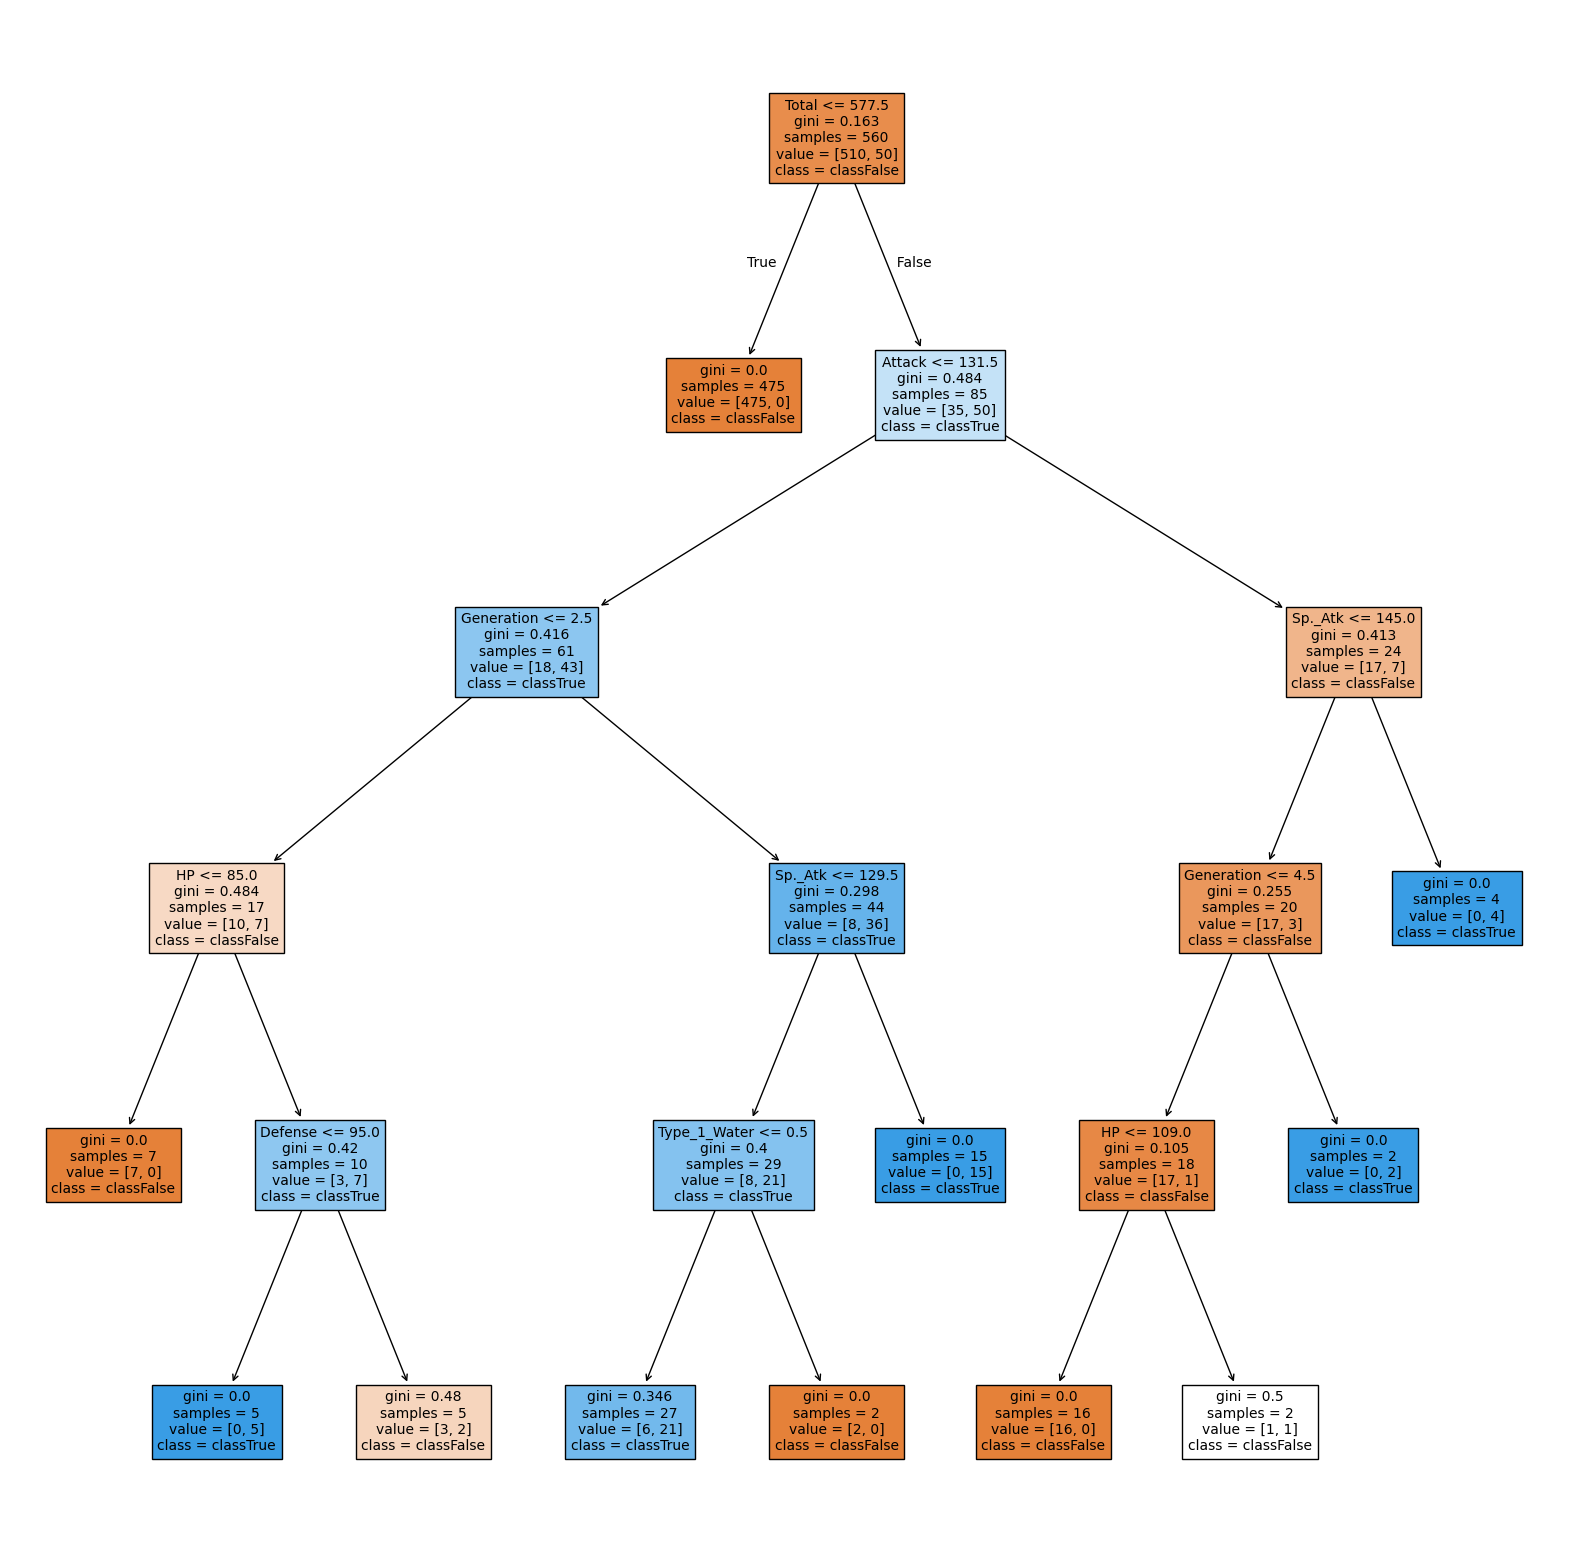

In [110]:
from sklearn import tree
class_name_list = [f"class{i}" for i in np.unique(y)]
plt.figure(figsize = (20,20))
tree.plot_tree(best_model.named_steps["classifier"],
               feature_names = all_feature,
               class_names = class_name_list,
               filled = True,
               fontsize = 10)
plt.show()